### importing necessary modules and set seed

In [46]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pyro
import random
import pyro.distributions as dist

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

## 1. Sampling unconstrained latent vectors from Guassian distribution and mapping to hyperbolic space

In [66]:
def sample_hyperbolic_positions(N: int, K:int, sigma_u: float=1.0, eps: float=1e-7):
    """This function samples unconstraind latent vectors from guassian distribution
    and maps them into the Poincaré model of hyperbolic space.
    
    Arguments:
        N(int): Number of leaves/ taxa 
        K(int): Number of dimensions of the latent vector
        sigma_u(float=1.0): scale of the unconstrained Guassian base prior
        eps(float=1e-7): stability constant for the origin.

    Output:
        tuple: (u,x) where u is the unconstrained latent vector [N,K] and x is hyperbolic position.
        """
    
    #1. Base prior: sampling latent vectors from guassian distribution u_i ~ N(0, sigma_u^2 * I)
    u = pyro.sample("u",
                     dist.Normal(0, sigma_u).expand([N, K]).to_event(2)) #samples from guassian distribution, 
    #expanding u to a N x K matrix and treating both dimensions as one joint object not independent
    #N x K


    #2. Computing the norm of each vector ||u_i||
    u_norm = torch.norm(u, p=2 , dim=-1, keepdim=True) # Euclidean norm , along K axis (for each N taxa, computes norm across K features)
    # N x 1


    #3. Apply the hyperbolic mapping: x_i = tanh(||u_i||) * (u_i/||u_i||)
    #we stabilize the denominator to prevent division by 0
    u_norm_stable = torch.clamp(u_norm, min=eps) #if u_norm[i] < eps → replace it with eps
    x_direction = u / u_norm_stable #unit vector in euclidean space
    x_magnitude = torch.tanh(u_norm) #squashed magnitude [0,1]
    x = x_direction * x_magnitude
    # [N,1] * [N,K] / [ N,1] => [N,K]

    return u,x

_,x = sample_hyperbolic_positions(N=50, K=2)
U,_ = sample_hyperbolic_positions(N=50, K=2)
print(U)

tensor([[ 0.0853,  0.7481],
        [-0.1636, -0.9086],
        [ 0.3130,  0.8050],
        [-1.1134,  0.5258],
        [-1.2000,  0.1271],
        [ 0.4404,  0.6378],
        [ 0.1598,  1.7698],
        [ 0.6268, -0.4976],
        [ 2.3259, -0.9204],
        [ 0.6661, -0.4403],
        [-2.3180,  1.2946],
        [ 0.2227, -1.2924],
        [ 1.6489,  1.6006],
        [-0.0786,  0.4310],
        [ 0.3684,  0.7638],
        [ 1.1792,  0.0830],
        [ 0.5184, -0.7015],
        [-0.4323,  0.1415],
        [ 0.0711,  0.5634],
        [-0.5786, -1.2299],
        [-0.3889,  0.8126],
        [ 1.4981,  0.0439],
        [ 1.4443,  0.2320],
        [ 0.5065, -0.9178],
        [-0.0384,  1.9138],
        [ 0.3378,  0.1251],
        [-0.7622, -1.1906],
        [ 0.7756, -0.9437],
        [ 0.2503, -1.3611],
        [ 1.8018, -0.0743],
        [-0.1566, -0.8708],
        [-0.6411,  0.5374],
        [-0.6902, -0.2300],
        [-2.1723,  0.0877],
        [ 1.0938, -0.1177],
        [-0.2986,  1

Base prior: $$u_{i} \sim \mathcal{N}(0, \sigma_{u}^{2}I), \quad i=1, \dots, N $$

Hyperbolic mapping:
$$x_{i} = g(u_{i}) = \tanh(||u_{i}||_{2}) \frac{u_{i}}{||u_{i}||_{2}}$$

### Checking that all points are inside Poincaré ball



In [48]:
# (norm < 1)
norms = torch.norm(x, p=2, dim=-1)
print(f"Max norm: {norms.max().item():.4f}")
print(f"Min norm: {norms.min().item():.4f}")

if torch.any(norms >= 1.0):
    print("Warning: Some points are outside the Poincaré ball!")

Max norm: 0.9860
Min norm: 0.2311


### Visualizing N points in the Poincaré disk


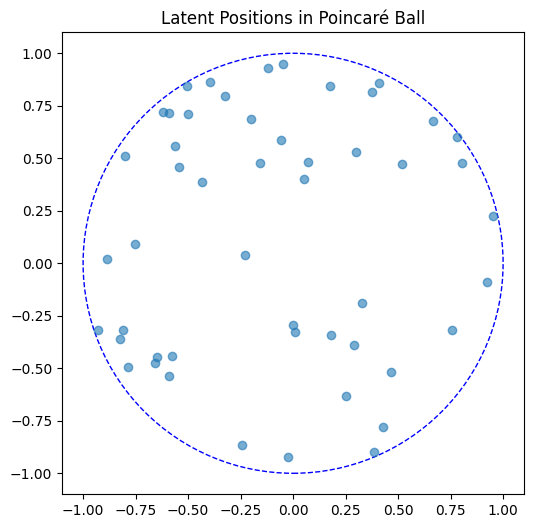

In [49]:
import matplotlib.pyplot as plt

def plot_poincare_points(x: torch.Tensor):
    """takes tensor of x latent points as inputs and visualizes them within 2D poincare disk"""
    if x.shape[1] !=2:
        print("Visualization only supported for K=2")
        return
    
    fig,ax = plt.subplots(figsize=(6,6))
    circle = plt.Circle((0,0), 1, fill= False, color= "blue", linestyle= "--") #poincare boundary , radius =1
    ax.add_artist(circle)

    # Detach from the gradient tape for plotting
    x_np = x.detach().cpu().numpy()
    ax.scatter(x_np[:, 0], x_np[:, 1], alpha=0.6)
    
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect('equal')
    plt.title("Latent Positions in Poincaré Ball")
    plt.show()

plot_poincare_points(x)



## 2. Computing hyperbolic distance matrix


In [50]:
def compute_distance_matrix (x: torch.Tensor, eps:float = 1e-7):
    """this function computes the pairwise distance matrix for x latent positions in the hyperbolic space.
    
    Arguments:
    x (Tensor): hyperbolic latent positions [N,K] 
    eps (float=1e-7): Numerical stability constant for the arcosh argument
    
    Returns:
    Tensor: Induced distance matrix D [N,N]"""

    #1. computing squared norm for each point:  ||x_i||^2
    #this is the distance of the point from origin in the ball
    x_sq_norm = torch.sum(x**2, dim=-1) #takes all x values for a particular row across columns, squares them and sums up
    #[N]

    #2. computing squared pairwise distances : ||x_i - x_j||^2
    dist_sq = torch.cdist(x, x, p=2)**2  #p=2 specifies Euclidean distance
    #for every value across K, difference between every pair of taxa (rows) is calculated and squared, summed across all Ks.
    #[N,N]

    #3. Computing the hyperbolic distance formula :
    #d(x_i, x_j) = arcosh(1 + 2 * ||x_i - x_j||^2 / ((1 - ||x_i||^2) * (1 - ||x_j||^2)))
    
    denom = (1 - x_sq_norm.unsqueeze(1)) * (1 - x_sq_norm.unsqueeze(0)) #[N,1] and [1,N]
    #[N,N]

    # Clamp the denominator and the argument of arcosh to prevent NaN
    arg = 1 + 2 * dist_sq / torch.clamp(denom, min=eps)

    return torch.acosh(torch.clamp(arg, min=1.0+eps)) #[N,N]

hyperbolic_dist_matrix = compute_distance_matrix(x)


Induced hyperbolic distance matrix D:
$$D_{i,j} = d_{\mathbb{H}}(x_{i},x_{j}) = \operatorname{arcosh}\left(1 + 2 \frac{||x_{i} - x_{j}||_{2}^{2}}{(1 - ||x_{i}||_{2}^{2})(1 - ||x_{j}||_{2}^{2})}\right)$$

### Visualizing the hyperbolic distance matrix

In [51]:
#converting into a labelled dataframe
import pandas as pd
hyperbolic_np = hyperbolic_dist_matrix.detach().cpu().numpy()
taxon_labels = [f"Taxon_{i}" for i in range(hyperbolic_np.shape[0])]
hyperbolic_df = pd.DataFrame(hyperbolic_np, index= taxon_labels, columns=taxon_labels)
print(hyperbolic_df.iloc[:5, :5])

          Taxon_0   Taxon_1   Taxon_2   Taxon_3   Taxon_4
Taxon_0  0.000488  8.978870  7.138558  7.875814  7.542786
Taxon_1  8.978870  0.000488  2.284365  4.741284  8.204395
Taxon_2  7.138558  2.284365  0.000488  3.413097  6.440319
Taxon_3  7.875814  4.741284  3.413097  0.000488  6.782805
Taxon_4  7.542786  8.204395  6.440319  6.782805  0.000488


### Visualizing the hyperbolic distance matrix as a heatmap


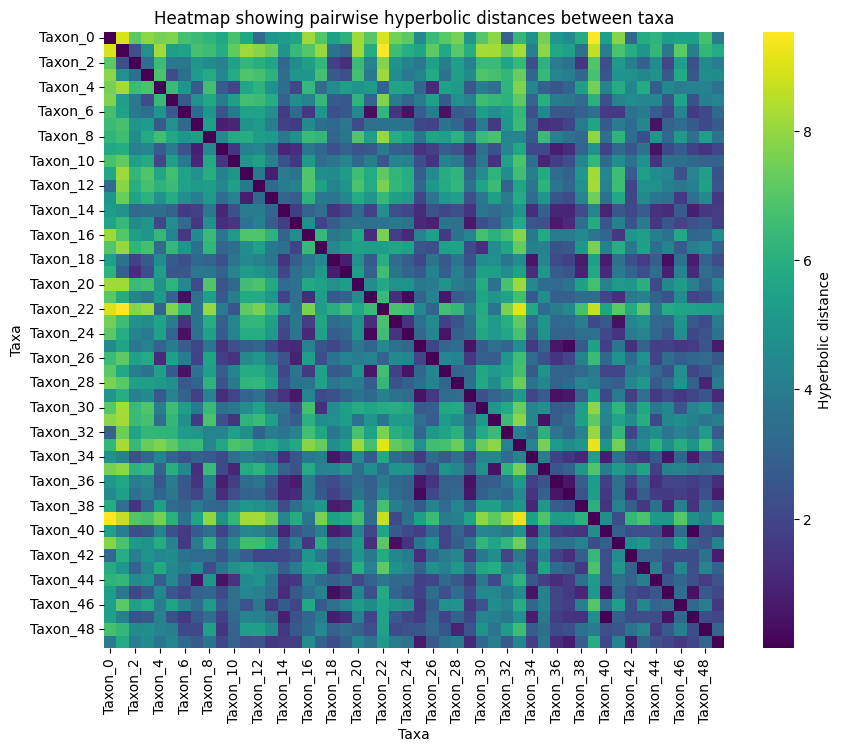

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(hyperbolic_df, cmap='viridis', annot =False, cbar_kws={'label':'Hyperbolic distance'})

plt.title('Heatmap showing pairwise hyperbolic distances between taxa')
plt.xlabel('Taxa')
plt.ylabel('Taxa')
plt.show()



## 3. Quartet subsampling

In [58]:
def get_fixed_quartets (N: int , B: int, seed:int = 42):
    """This function gives a fixed subset of quartets.

    Arguments:
    N (int): Number of leaves
    B (int): Number fixed of quartets 
    
    Outputs:
    torch.Tensor : tensor of indices [B,4]"""
    torch.manual_seed(seed)
    quartets = [] #empty list
    for _ in range (B):
        #sample 4 unique indices from N taxa
        q = torch.randperm(N)[:4]
        quartets.append(q)
    return torch.stack(quartets)

sampled_quartets = get_fixed_quartets(N =50, B= 5)
sampled_quartets #[B,4]

tensor([[42, 17, 30, 34],
        [27, 23, 47, 11],
        [11, 49, 48, 21],
        [18,  7,  9, 39],
        [13, 28, 30,  2]])

We need to sample sets of 4 unique indices from N taxa, this is done by subsampling $B$ quartets out of total $(^N _ 4)$ quartets

## 4. Differentiable four-point penalty 


Once the subset of quartets is obtained, for each quartet the three quartets $s1, s2, s3$ are calculated.
This is followed by computing softplus penalty for each quartet.

$$\zeta_{\tau}(x) = \tau \log(1 + \exp(x/\tau))$$

$$p(q;D) = \sum_{k=1}^{3} \prod_{j \neq k} \zeta_{\tau}(s_{k} - s_{j})$$






In [64]:
def soft_four_point_penalty (D:torch.Tensor, sampled_quartets:torch.Tensor, tau =0.1):
    """this function computes the soft four point penalty for each quartet p(q;D) and sums it up for the entire subset of quartets to give total penalty.
    This penalty is small when the sums are tree like (s1 <s2=s3) , large when one of the sum is largest."""

    #1. Extracting distances for each quartet (a,b,c,d)
    a, b, c, d =  sampled_quartets[: ,0] , sampled_quartets[: ,1], sampled_quartets[: ,2], sampled_quartets[: ,3]

    #2. Computing the sums s1, s2, s3
    s1= D[a,b] + D[c,d]
    s2= D[a,c] + D[b,d]
    s3 = D[a,d] + D[b,c]

    sums = torch.stack([s1,s2,s3], dim= -1) #shape : [B,3]

    #3. Computing the differentiable penalty
    # we want to compare each s_k with other two sums 
    penalty = 0

    for k in range(3):
        #current sum
        s_curr = sums[:, k]

        other_indices = [j for j in range(3) if j != k]
        #other two sums
        s_other1 = sums[:, other_indices[0]]
        s_other2 = sums[:, other_indices[1]]

        #computing zeta_tau(s_k - s_j) for both other sums
        #z1 = zeta_tau(s1-s2) ; z2 =zeta_tau(s1-s3)
        z1 = tau* torch.log(1+torch.exp((s_curr-s_other1)/tau))
        z2 = tau* torch.log(1+torch.exp((s_curr-s_other2)/tau))

        #penalty for this quartet computed by multiplying zeta of this value of k
        penalty += (z1*z2) #sums the penalties across k=0 to 2
    
    return penalty #p(q ; D)

all_penalties = soft_four_point_penalty(hyperbolic_dist_matrix,sampled_quartets)
total_penalty = all_penalties.sum()
print(f"Total Penalty for all {len(all_penalties)} quartets: {total_penalty.item()}")



Total Penalty for all 5 quartets: 4.071852684020996


## 5. Penalized prior

### Defining base prior

We assume that each value in the unconstraint latent vector matrix $U$ is drawn from a standard normal distribution : 

$$p_0(U) = \prod_{i=1}^{N} \mathcal{N}(u_i;\, 0,\ \sigma_u^2 I)$$


The probability density for Guassian distribution :$$p(u) \propto e^{-\frac{1}{2}u^2}$$



Taking log $$U(\mathcal{U}) = -\log p(U)$$

$$-\log(p(u)) = -(-\frac{1}{2}u^2) = \frac{1}{2}u^2$$

### Penalty component
The penalty for the entire set of sampled quartets $\mathcal{Q}$ is represented as:

$$\lambda P(h(U)) = \lambda \sum_{q \in \mathcal{Q}} \sum_{k=1}^{3} \prod_{j \neq k} \zeta_{\tau} \big( s_k(q) - s_j(q) \big)$$

### total potential energy is:

$$U(\mathcal{U}) = -\log p_0(U) + \lambda P(h(U))$$

In [70]:
def compute_energy_function(U, hyperbolic_dist_matrix, sampled_quartets, lmbda=1.0, sigma=1.0, tau=0.1):
    """
    Computes the total Potential Energy U(U).
    U(U) = -log p0(U) + lmbda * P(D)
    """
    
    # 1. Base Prior: -log p0(U)
    base_prior = torch.sum(U**2) / (2 * sigma**2)

    # 2. Penalty Component: lambda * P(D)
    # The "Tree Force" pushing points into a hierarchy.
    # We sum the quartet penalties and scale by lambda.
    penalty_component = lmbda * total_penalty

    # 3. Total Potential Energy U(U)
    energy = base_prior + penalty_component

    return energy

potential_energy = compute_energy_function(U , hyperbolic_dist_matrix, sampled_quartets)
print(potential_energy)

tensor(57.9662)


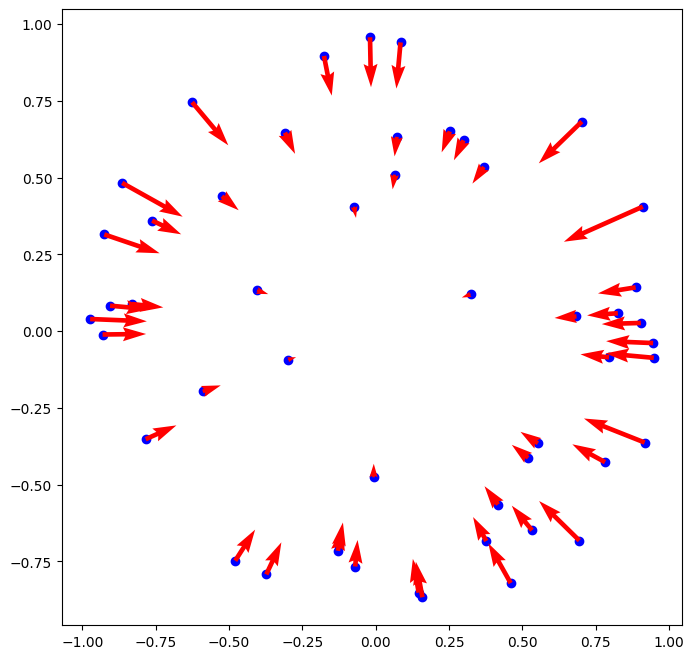

In [72]:
def visualize_taxa_dynamics(U, sampled_quartets, lmbda, sigma, tau):
    # Enable gradient tracking on raw U
    U_grad = U.clone().detach().requires_grad_(True)
    
    # Forward pass through the pipeline
    X = torch.tanh(torch.norm(U_grad, dim=-1, keepdim=True)) * (U_grad / (torch.norm(U_grad, dim=-1, keepdim=True) + 1e-5))
    D = compute_distance_matrix(X) # Your distance function here
    
    # Calculate Energy
    energy = compute_energy_function(U_grad, D, sampled_quartets, lmbda, sigma, tau)
    
    # Backward pass to find the "Force"
    energy.backward()
    forces = -U_grad.grad.detach()
    
    # Convert to numpy for plotting
    X_plot = X.detach().cpu().numpy()
    F_plot = forces.cpu().numpy()
    
    # Plotting code
    plt.figure(figsize=(8,8))
    plt.scatter(X_plot[:, 0], X_plot[:, 1], c='blue') # Plot on the Disk!
    plt.quiver(X_plot[:, 0], X_plot[:, 1], F_plot[:, 0], F_plot[:, 1], color='red')
    plt.show()


visualize_taxa_dynamics(U, sampled_quartets, lmbda= 1.0 , sigma=1.0, tau=0.1)